<a href="https://colab.research.google.com/github/Sam-Gyu/Crop-Yield-Prediction-/blob/main/crop_yield_prediction.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# Import Important libraries

In [76]:
import numpy as np
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt
import warnings
warnings.filterwarnings('ignore')

# Data Loading and Inspection

In [77]:
df = pd.read_csv('yield_df.csv')
df.head()

,Unnamed: 0,Area,Item,Year,hg/ha_yield,average_rain_fall_mm_per_year,pesticides_tonnes,avg_temp
0,0,Albania,Maize,1990,36613,1485.0,121.0,16.37
1,1,Albania,Potatoes,1990,66667,1485.0,121.0,16.37
2,2,Albania,"Rice, paddy",1990,23333,1485.0,121.0,16.37
3,3,Albania,Sorghum,1990,12500,1485.0,121.0,16.37
4,4,Albania,Soybeans,1990,7000,1485.0,121.0,16.37


In [78]:
df.drop('Unnamed: 0', axis=1, inplace=True)

In [79]:
df.head()

,Area,Item,Year,hg/ha_yield,average_rain_fall_mm_per_year,pesticides_tonnes,avg_temp
0,Albania,Maize,1990,36613,1485.0,121.0,16.37
1,Albania,Potatoes,1990,66667,1485.0,121.0,16.37
2,Albania,"Rice, paddy",1990,23333,1485.0,121.0,16.37
3,Albania,Sorghum,1990,12500,1485.0,121.0,16.37
4,Albania,Soybeans,1990,7000,1485.0,121.0,16.37


In [80]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 28242 entries, 0 to 28241
Data columns (total 7 columns):
 #   Column                         Non-Null Count  Dtype  
---  ------                         --------------  -----  
 0   Area                           28242 non-null  object 
 1   Item                           28242 non-null  object 
 2   Year                           28242 non-null  int64  
 3   hg/ha_yield                    28242 non-null  int64  
 4   average_rain_fall_mm_per_year  28242 non-null  float64
 5   pesticides_tonnes              28242 non-null  float64
 6   avg_temp                       28242 non-null  float64
dtypes: float64(3), int64(2), object(2)
memory usage: 1.5+ MB


In [81]:
df.isnull().sum()

,0
Area,0
Item,0
Year,0
hg/ha_yield,0
average_rain_fall_mm_per_year,0
pesticides_tonnes,0
avg_temp,0


In [82]:
df.shape

(28242, 7)

In [83]:
df.duplicated().sum()

np.int64(2310)

In [84]:
df.drop_duplicates(inplace=True)

In [85]:
df.duplicated().sum()

np.int64(0)

# Exploratory Data Analysis (EDA)

In [86]:
df.columns

Index(['Area', 'Item', 'Year', 'hg/ha_yield', 'average_rain_fall_mm_per_year',
       'pesticides_tonnes', 'avg_temp'],
      dtype='object')

In [87]:
len (df['Area'].unique())

101

Count Plot: Graph Frequency vs Area

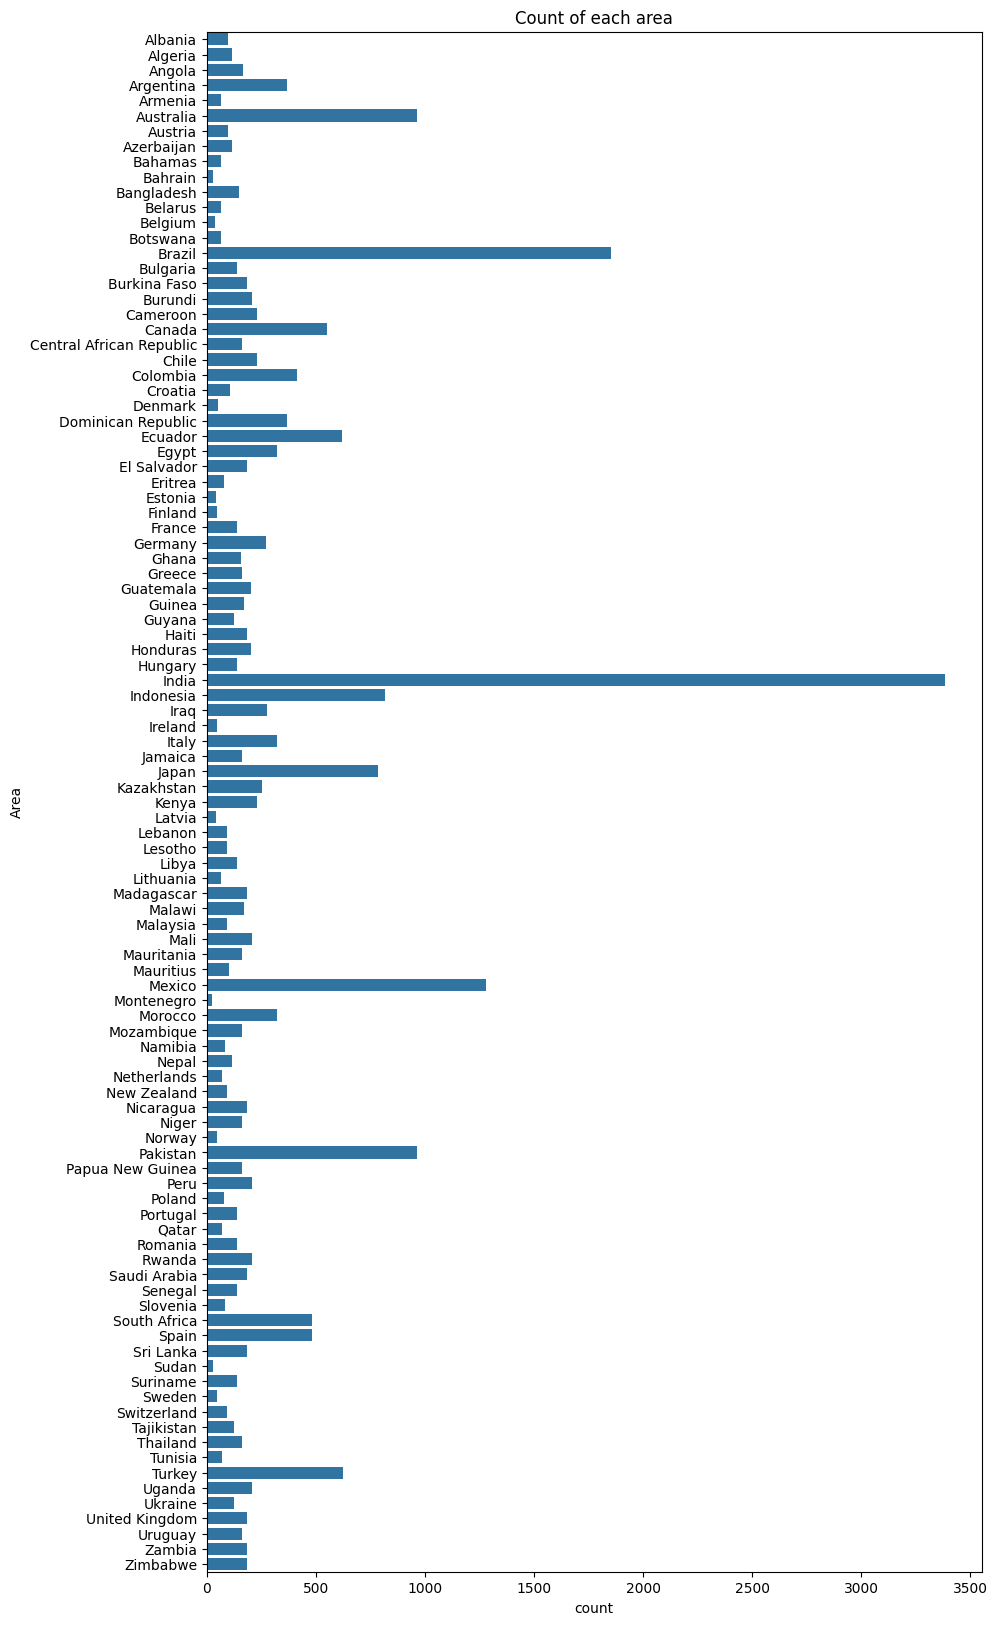

In [88]:
plt.figure(figsize=(10,20))
sns.countplot(y=df['Area'])
plt.title('Count of each area')
plt.show()

In [89]:
(df['Area'].value_counts() < 500).sum()

np.int64(91)

barplot to show Average Agricultural Yield by Country

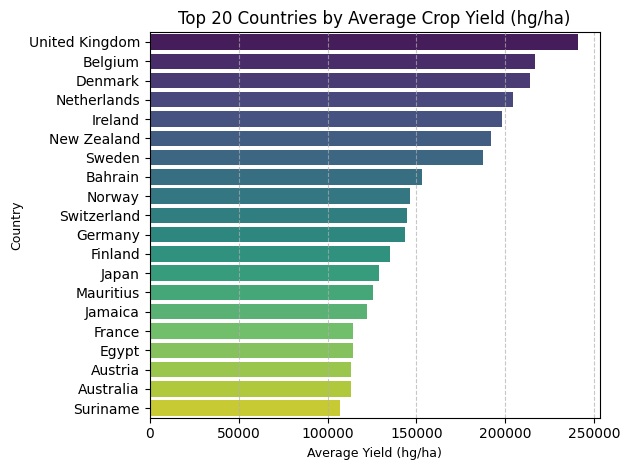

In [90]:
# Group by Area and calculate the mean yield -> Splits the data into buckets based on the country name and Calculates the average yield for each country.
# We sort the values so the most productive countries appear at the top
avg_yield_per_country = df.groupby('Area')['hg/ha_yield'].mean().sort_values(ascending=False).reset_index()

# Select Top 20 for better visibility
top_countries = avg_yield_per_country.head(20)

# Create the visualization
sns.barplot(
    data=top_countries,
    y='Area',
    x='hg/ha_yield',
    palette='viridis'
)

plt.title('Top 20 Countries by Average Crop Yield (hg/ha)', fontsize=12)
plt.xlabel('Average Yield (hg/ha)', fontsize=9)
plt.ylabel('Country', fontsize=9)
plt.grid(axis='x', linestyle='--', alpha=0.7)

plt.tight_layout()
plt.show()

barplot to show Average Agricultural Yield by Crop

In [91]:
print(f'Unique Items: {(df['Item'].unique())}')
print(len(df['Item'].unique()))

Unique Items: ['Maize' 'Potatoes' 'Rice, paddy' 'Sorghum' 'Soybeans' 'Wheat' 'Cassava'
 'Sweet potatoes' 'Plantains and others' 'Yams']
10


<Axes: xlabel='count', ylabel='Item'>

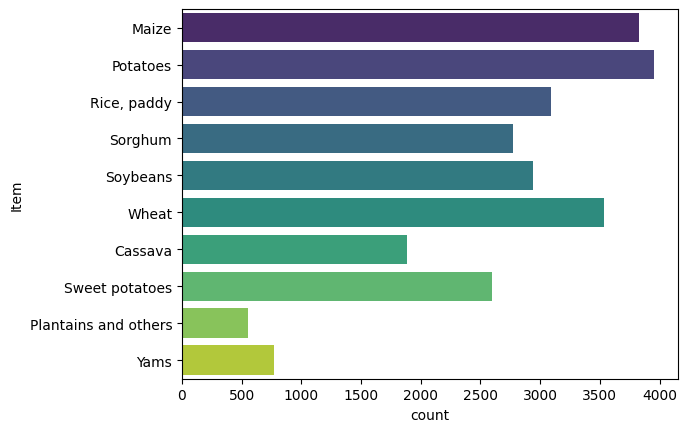

In [92]:
sns.countplot(y=df['Item'], palette='viridis')

barplot to visualize the total productivity (Sum of hg/ha_yield) for each crop

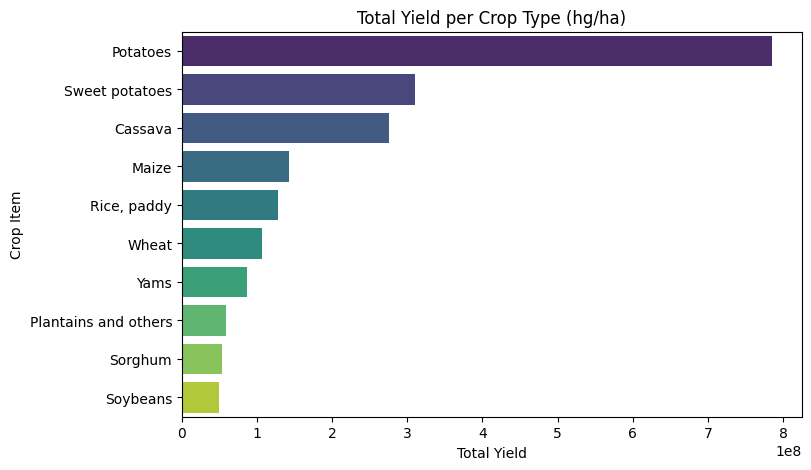

In [93]:
sum_yield_per_item = df.groupby('Item')['hg/ha_yield'].sum().sort_values(ascending=False).reset_index()

plt.figure(figsize=(8, 5))
sns.barplot(x='hg/ha_yield', y='Item', data=sum_yield_per_item, palette='viridis')

plt.title('Total Yield per Crop Type (hg/ha)')
plt.xlabel('Total Yield')
plt.ylabel('Crop Item')
plt.show()

Correlation Heatmap: This helps us to see which variables are strongly related.

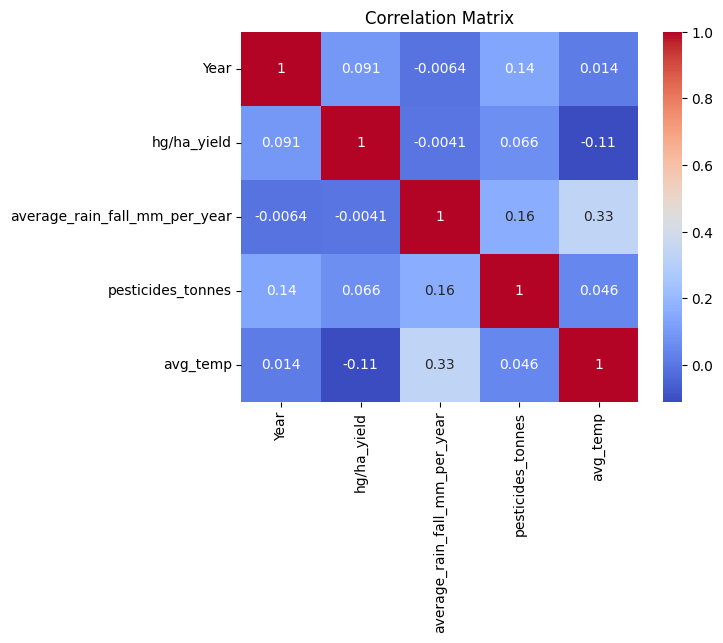

In [94]:
# This filters the dataframe to only include numeric data types
numeric_df = df.select_dtypes(include=['number'])
corr = numeric_df.corr()

sns.heatmap(corr, annot=True, cmap='coolwarm')
plt.title("Correlation Matrix")
plt.show()

# Train_Test_Split & Rearrange columns

In [95]:
df.head()

,Area,Item,Year,hg/ha_yield,average_rain_fall_mm_per_year,pesticides_tonnes,avg_temp
0,Albania,Maize,1990,36613,1485.0,121.0,16.37
1,Albania,Potatoes,1990,66667,1485.0,121.0,16.37
2,Albania,"Rice, paddy",1990,23333,1485.0,121.0,16.37
3,Albania,Sorghum,1990,12500,1485.0,121.0,16.37
4,Albania,Soybeans,1990,7000,1485.0,121.0,16.37


In [96]:
col = ['Area', 'Item', 'Year', 'average_rain_fall_mm_per_year', 'pesticides_tonnes', 'avg_temp', 'hg/ha_yield']
df = df[col]
df.head()

,Area,Item,Year,average_rain_fall_mm_per_year,pesticides_tonnes,avg_temp,hg/ha_yield
0,Albania,Maize,1990,1485.0,121.0,16.37,36613
1,Albania,Potatoes,1990,1485.0,121.0,16.37,66667
2,Albania,"Rice, paddy",1990,1485.0,121.0,16.37,23333
3,Albania,Sorghum,1990,1485.0,121.0,16.37,12500
4,Albania,Soybeans,1990,1485.0,121.0,16.37,7000


In [97]:
X = df.drop('hg/ha_yield', axis=1)
y = df['hg/ha_yield']

In [98]:
from sklearn.model_selection import train_test_split
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)


# Converting Categorical to Numerical and Scaling the values

In [99]:
df.head(1)

,Area,Item,Year,average_rain_fall_mm_per_year,pesticides_tonnes,avg_temp,hg/ha_yield
0,Albania,Maize,1990,1485.0,121.0,16.37,36613


In [100]:
from sklearn.preprocessing import OneHotEncoder, StandardScaler
from sklearn.compose import ColumnTransformer

# Initialize the encoders and scalers
# This will convert categorical columns into numeric columns
ohe = OneHotEncoder(drop='first')

# This will scale numerical columns to have mean=0 and std=1
scale = StandardScaler()

# Create the ColumnTransformer
# This lets us apply different transformers to different columns
preprocessor = ColumnTransformer(
    transformers = [
        # ('name of transformation', transformer object, column indices)
        ('StandardScale', scale, [2, 3, 4, 5]), # Scaling numerical features (Yield, Rain, Pesticides, Temp)
        ('OneHOtEncoder', ohe, [0, 1]),                   # Encoding categorical features (Area, Item)
    ],
    remainder='passthrough'                    # Keep any other columns as they are
)

# fit_transform
# - fit -> learn from the training data (mean, std, or unique categories)
# - transform -> apply the transformation
X_train_processed  = preprocessor.fit_transform(X_train)

# transform only (no fit)
# so the test data is transformed using the same parameters learned from training
X_test_processed  = preprocessor.transform(X_test)

In [101]:
preprocessor.get_feature_names_out()

array(['StandardScale__Year',
       'StandardScale__average_rain_fall_mm_per_year',
       'StandardScale__pesticides_tonnes', 'StandardScale__avg_temp',
       'OneHOtEncoder__Area_Algeria', 'OneHOtEncoder__Area_Angola',
       'OneHOtEncoder__Area_Argentina', 'OneHOtEncoder__Area_Armenia',
       'OneHOtEncoder__Area_Australia', 'OneHOtEncoder__Area_Austria',
       'OneHOtEncoder__Area_Azerbaijan', 'OneHOtEncoder__Area_Bahamas',
       'OneHOtEncoder__Area_Bahrain', 'OneHOtEncoder__Area_Bangladesh',
       'OneHOtEncoder__Area_Belarus', 'OneHOtEncoder__Area_Belgium',
       'OneHOtEncoder__Area_Botswana', 'OneHOtEncoder__Area_Brazil',
       'OneHOtEncoder__Area_Bulgaria', 'OneHOtEncoder__Area_Burkina Faso',
       'OneHOtEncoder__Area_Burundi', 'OneHOtEncoder__Area_Cameroon',
       'OneHOtEncoder__Area_Canada',
       'OneHOtEncoder__Area_Central African Republic',
       'OneHOtEncoder__Area_Chile', 'OneHOtEncoder__Area_Colombia',
       'OneHOtEncoder__Area_Croatia', 'OneHOtEnc

In [102]:
import pandas as pd

# Convert the transformed output (X_train_processed) into a readable DataFrame.
# We use .toarray() because OneHotEncoder often returns a 'Sparse Matrix' (to save memory).
# Converting it to a 'Dense' array allows Pandas to display it as a full table.
X_train_processed = pd.DataFrame(
    X_train_processed.toarray() if hasattr(X_train_processed, "toarray") else X_train_processed,

    # Assign the correct column names.
    # get_feature_names_out() retrieves the names like 'OHE__Area_Egypt' or 'StandardScale__avg_temp'
    columns=preprocessor.get_feature_names_out()
)

# Display the first 20 rows of the processed data to verify scaling and encoding.
X_train_processed.head(20)

,StandardScale__Year,StandardScale__average_rain_fall_mm_per_year,StandardScale__pesticides_tonnes,StandardScale__avg_temp,OneHOtEncoder__Area_Algeria,OneHOtEncoder__Area_Angola,OneHOtEncoder__Area_Argentina,OneHOtEncoder__Area_Armenia,OneHOtEncoder__Area_Australia,OneHOtEncoder__Area_Austria,...,OneHOtEncoder__Area_Zimbabwe,OneHOtEncoder__Item_Maize,OneHOtEncoder__Item_Plantains and others,OneHOtEncoder__Item_Potatoes,"OneHOtEncoder__Item_Rice, paddy",OneHOtEncoder__Item_Sorghum,OneHOtEncoder__Item_Soybeans,OneHOtEncoder__Item_Sweet potatoes,OneHOtEncoder__Item_Wheat,OneHOtEncoder__Item_Yams
0,-0.219261,-1.515499,-0.552688,0.949843,0.0,0.0,0.0,0.0,0.0,0.0,...,0.0,0.0,0.0,0.0,0.0,1.0,0.0,0.0,0.0,0.0
1,1.483365,-0.688335,-0.464678,-0.250231,0.0,0.0,0.0,0.0,0.0,0.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,1.0,0.0,0.0
2,0.632052,2.921614,1.132241,1.098882,0.0,0.0,0.0,0.0,0.0,0.0,...,0.0,1.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
3,1.199594,-0.681361,-0.547719,0.114604,0.0,0.0,0.0,0.0,0.0,0.0,...,1.0,0.0,0.0,1.0,0.0,0.0,0.0,0.0,0.0,0.0
4,0.773937,0.368984,-0.505560,1.032125,0.0,0.0,0.0,0.0,0.0,0.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,1.0,0.0,0.0
5,-1.496230,-0.087142,0.669117,1.074042,0.0,0.0,0.0,0.0,0.0,0.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
6,0.064510,-0.087142,0.144915,0.883086,0.0,0.0,0.0,0.0,0.0,0.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,1.0,0.0,0.0
7,0.773937,-0.087142,-0.121334,1.105092,0.0,0.0,0.0,0.0,0.0,0.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,1.0,0.0
8,0.064510,0.728863,0.636049,-0.674060,0.0,0.0,0.0,0.0,0.0,0.0,...,0.0,0.0,0.0,1.0,0.0,0.0,0.0,0.0,0.0,0.0
9,1.483365,-0.554427,-0.591249,1.278971,0.0,0.0,0.0,0.0,0.0,0.0,...,0.0,1.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0


# Model Training and Comparative Evaluation

In [103]:
#linear regression
from sklearn.linear_model import LinearRegression,Lasso,Ridge
from sklearn.neighbors import KNeighborsRegressor
from sklearn.tree import DecisionTreeRegressor
from sklearn.metrics import mean_absolute_error,r2_score

# Model Dictionary
model = {
    'lr':LinearRegression(),
    'lss':Lasso(),
    'rid':Ridge(),
    'Dtr':DecisionTreeRegressor()
}


for name, md in model.items():
  md.fit(X_train_processed, y_train )
  y_pred = md.predict(X_test_processed)
  mae = mean_absolute_error(y_test, y_pred)
  score = r2_score(y_test, y_pred)
  print(f'{name} : mae : {mae}, score : {score}')

lr : mae : 29920.7419357517, score : 0.7486562040956108
lss : mae : 29907.641382490678, score : 0.7485842409647621
rid : mae : 29875.800781273923, score : 0.7485388180308394
Dtr : mae : 4131.766146134567, score : 0.9766168350697685


# Select Model

In [104]:
Dtr = DecisionTreeRegressor()
Dtr.fit(X_train_processed,y_train)
Dtr.predict(X_test_processed)

array([167489.,  15838.,  72614., ...,  52692.,   9621., 132600.])

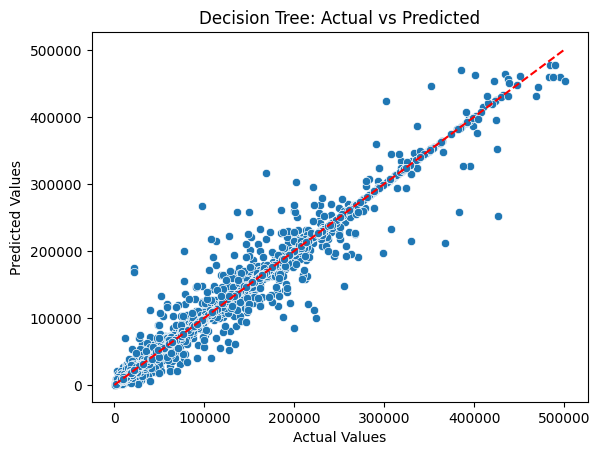

In [105]:
plt.figure()
sns.scatterplot(x=y_test, y=y_pred)
min_val = min(y_test.min(), y_pred.min())
max_val = max(y_test.max(), y_pred.max())
plt.plot([min_val, max_val], [min_val, max_val], 'r--')

plt.xlabel("Actual Values")
plt.ylabel("Predicted Values")
plt.title("Decision Tree: Actual vs Predicted")

plt.show()

# Predictive Case

In [106]:
def prediction(Year, average_rain_fall_mm_per_year, pesticides_tonnes, avg_temp, Area, Item):

    # Create a DataFrame
    features = pd.DataFrame({
        'Year': [Year],
        'average_rain_fall_mm_per_year': [average_rain_fall_mm_per_year],
        'pesticides_tonnes': [pesticides_tonnes],
        'avg_temp': [avg_temp],
        'Area': [Area],
        'Item': [Item]
    })

    transformed_features = preprocessor.transform(features)

    predicted_yield = Dtr.predict(transformed_features)

    return predicted_yield[0]

In [107]:
target_year = 1990
rain = 1485.0
pesticides = 121.0
temp = 16.37
country = 'Albania'
crop = 'Maize'

yield_result = prediction (target_year, rain, pesticides, temp, country, crop)

print(f"Prediction for {crop} in {country} ({target_year}):")
print(f"==> Predicted Yield: {yield_result:.2f} hg/ha")

Prediction for Maize in Albania (1990):
==> Predicted Yield: 36613.00 hg/ha
